After my group and I experimented with the wine categorizer, i wanted to make my own ai using the same methods i learned. the purpise is a ai phishing bot that detects phising websites which is still a issue in modern time.

In [2]:
#importing library 
import pandas as pd
import numpy as np


In [4]:
#loading my dataset(this is a unverified one from kaggal)
df = pd.read_csv("phishing.csv", sep=",")



Although the function defaults to detecting the seperation with commas i still included the sep function for good practice so i can remember to check the csv file to verify if it's seperated by , ; or .

In [6]:
df.describe()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
count,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,...,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000
mean,5526.500000,0.313914,-0.633345,0.738737,0.700561,0.741632,-0.734938,0.064049,0.251040,-0.336711,...,0.613353,0.816899,0.061335,0.377239,0.287407,-0.483626,0.721549,0.343948,0.719739,0.113986
std,3191.159272,0.949495,0.765973,0.674024,0.713625,0.670837,0.678165,0.817492,0.911856,0.941651,...,0.789845,0.576807,0.998162,0.926158,0.827680,0.875314,0.692395,0.569936,0.694276,0.993527
min,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2763.250000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,5526.500000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,8289.750000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,11053.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


These are some large numbers so later on i will use standardscale to scale it down for faster learning

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Symbol@              11054 non-null  int64
 5   Redirecting//        11054 non-null  int64
 6   PrefixSuffix-        11054 non-null  int64
 7   SubDomains           11054 non-null  int64
 8   HTTPS                11054 non-null  int64
 9   DomainRegLen         11054 non-null  int64
 10  Favicon              11054 non-null  int64
 11  NonStdPort           11054 non-null  int64
 12  HTTPSDomainURL       11054 non-null  int64
 13  RequestURL           11054 non-null  int64
 14  AnchorURL            11054 non-null  int64
 15  LinksInScriptTags    11054 non-null  int64
 16  ServerFormHandler    1

now because there is no text there is no need for me to use the encoder to change anything into a integer, as you can see above everything is a integer so the model can study this without any issues.

In [ ]:
df.isnull().sum()
#checking dataframe for any negative or extreme values.
# this can conclude that the data is okay.

Index                  0
UsingIP                0
LongURL                0
ShortURL               0
Symbol@                0
Redirecting//          0
PrefixSuffix-          0
SubDomains             0
HTTPS                  0
DomainRegLen           0
Favicon                0
NonStdPort             0
HTTPSDomainURL         0
RequestURL             0
AnchorURL              0
LinksInScriptTags      0
ServerFormHandler      0
InfoEmail              0
AbnormalURL            0
WebsiteForwarding      0
StatusBarCust          0
DisableRightClick      0
UsingPopupWindow       0
IframeRedirection      0
AgeofDomain            0
DNSRecording           0
WebsiteTraffic         0
PageRank               0
GoogleIndex            0
LinksPointingToPage    0
StatsReport            0
class                  0
dtype: int64

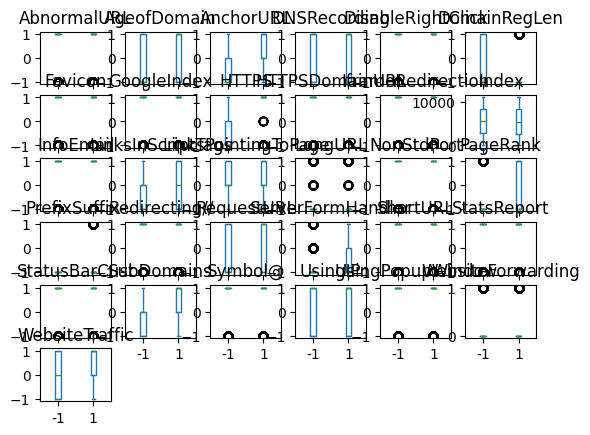

In [ ]:
plot = df.plot(kind="box", subplots=True, sharey=False, layout=(4,6), column=list(df.columns[:-1]), by="class")
# i can't get the correct layout to determine which features arent neccasary.


In [19]:
features = list(df.columns[:-1])
target = "class"
X = df[features]
y = df[target]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print("There are in total", len(X), "observations, of which", len(X_train), "are now in the train set, and", len(X_test), "in the test set.")

There are in total 11054 observations, of which 8843 are now in the train set, and 2211 in the test set.


so after importing required libraries, bringing in my csv file through pandas and inspecting that the data is okay, i've made a variable called features which is the list of features within the dataset, and a variable target which is the class column.
(Note: process begins with importing libraries, then bringing in csv file with pandas under variable data frame "df = pd.read_csv()" inspect the data by first describing it with df.describe and looking at the info using df.info then proceed with checking for negative and extreme values. after than we can see whihc features arent to useful with the plotbox chart whihc i could not get to work yet. then proceed to making the train and test split by distringuising the features with the target, it will train on distringuising the features and will be tested with the targets.)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
# as i mentioned prior there are large values so for quicker learning
# i scaled the values down

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)
model.fit(X_train, y_train)
pred = model.predict(X_test)
from sklearn.metrics import accuracy_score
score = accuracy_score(pred, y_test)
print("Accuracy:", score)




Accuracy: 0.9706015377657169


Im using randomforest because i asked chatgpt to look through the scikitlearn library and see which one would be best for the bot. i wanted to know how the parameters work, apparantly each forest holds a random set of data so the greater number of estimators the better,(there are more variables i can include within this but i've decided to leave the rest to how it would default, will research this later.)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))


              precision    recall  f1-score   support

          -1       0.97      0.96      0.97       957
           1       0.97      0.98      0.97      1254

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



: 

In [1]:
# my complete code for demonstration
import pandas as pd
import numpy as np
df = pd.read_csv("phishing.csv" , sep=",")
features = list(df.columns[:-1])
target = "class"
X = df[features]
y = df[target]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)
model.fit(X_train, y_train)
pred = model.predict(X_test)
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

          -1       0.98      0.96      0.97       977
           1       0.97      0.98      0.98      1234

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



From the wine categorizer one of my group members managed to figure out how to export the model, i will use his code to export and do some research on the library he used which will i will note below so i can learn.


In [ ]:
import numpy as np
from skl2onnx import to_onnx
from skl2onnx.common.data_types import FloatTensorType

X_train = X_train.astype(np.float32)

initial_type = [("input", FloatTensorType([None, X_train.shape[1]]))]
onx = to_onnx(model, initial_types=initial_type, target_opset=12)

with open("phishing_rf.onnx", "wb") as f:
    f.write(onx.SerializeToString())

Now from the material i read on onnx and from what my group members found the skl2onnx packages help convert models using the scikitlearn library into the onnx pipeline. the code above exports what i trained but without the scaler because i did not create a pipeline to do this. i did some research on what a pipeline was and A pipeline in scikit-learn is a structure that lets you chain multiple processing steps and a model into a single object that behaves like one model. BELOW i will provide the code with the pipeline so that it exports as one model.

In [5]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("phishing.csv", sep=",")
features = list(df.columns[:-1])
target = "class"

X = df[features]
y = df[target]

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(n_estimators=500, random_state=42))
])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, pred))



# Export to ONNX
from skl2onnx import to_onnx
from skl2onnx.common.data_types import FloatTensorType

initial_type = [("input", FloatTensorType([None, X_train.shape[1]]))]
onx = to_onnx(pipeline, initial_types=initial_type, target_opset=12)

with open("phishing_rf.onnx", "wb") as f:
    f.write(onx.SerializeToString())

              precision    recall  f1-score   support

          -1       0.96      0.96      0.96       976
           1       0.97      0.97      0.97      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211

